<a href="https://colab.research.google.com/github/Tejal-singhh/internship-tasks/blob/main/Tejalsingh_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving E-commerce_Customer_Segmentation_2026.csv to E-commerce_Customer_Segmentation_2026.csv


In [2]:
import pandas as pd
df = pd.read_csv("E-commerce_Customer_Segmentation_2026.csv")
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (50000, 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  object 
 1   customer_segment               50000 non-null  object 
 2   segment_category               50000 non-null  object 
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  object 
 5   gender                         50000 non-null  object 
 6   country                        50000 non-null  object 
 7   city                           50000 non-null  object 
 8   income_bracket                 50000 non-null  object 
 9   education_level                50000 non-null  object 
 10  employment_type                50000 non-null  object 
 11  marital_status                 50000 non-null  object 
 12  tenure_months              

The dataset has 50,000 customer records and 53 columns, giving a large, detailed base for segmentation.

In [4]:
df.isnull().sum()

,0
customer_id,0
customer_segment,0
segment_category,0
age,0
age_group,0
gender,0
country,0
city,0
income_bracket,0
education_level,0


No missing values in the core numeric columns we're using, so no cleaning was needed.

In [5]:
df[['avg_order_value_usd', 'total_purchases', 'total_spent_usd', 'customer_lifetime_value_usd']].describe()

,avg_order_value_usd,total_purchases,total_spent_usd,customer_lifetime_value_usd
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,505.366911,99.418460,50266.546156,57722.068910
std,285.604037,57.780178,44071.209164,52437.283546
min,10.050000,0.000000,0.000000,0.000000
25%,259.067500,49.000000,13893.577500,15488.650000
50%,504.790000,99.000000,37541.625000,42236.310000
75%,752.702500,150.000000,76811.242500,86714.875000
max,999.990000,199.000000,198574.140000,294634.150000


On average, customers spend $505 per order and have a lifetime value of ~$57,722, though these are just averages — actual behavior varies a lot between customers, which is exactly why we need clustering to find the different groups.

In [6]:
rfm = df[['customer_id', 'days_since_last_purchase', 'total_purchases', 'total_spent_usd']].copy()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST-000001,63,28,25552.80
1,CUST-000002,342,75,22564.50
2,CUST-000003,64,163,108217.33
3,CUST-000004,2,192,117811.20
4,CUST-000005,4,31,20201.15


Built a Recency-Frequency-Monetary (RFM) table by pulling days_since_last_purchase, total_purchases, and total_spent_usd for each customer — these three features capture how recently, how often, and how much each customer buys.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled[:5]

array([[ 3.08317481e-04, -1.23604974e+00, -5.60774115e-01],
       [ 2.99128805e+00, -4.22613863e-01, -6.28580965e-01],
       [ 1.10286750e-02,  1.10041502e+00,  1.31494834e+00],
       [-6.53633488e-01,  1.60232227e+00,  1.53264071e+00],
       [-6.32192773e-01, -1.18412831e+00, -6.82207214e-01]])

Standardized Recency, Frequency, and Monetary so they're on the same scale — otherwise Monetary (in thousands of dollars) would dominate clustering just because its numbers are bigger, not because it's more important.

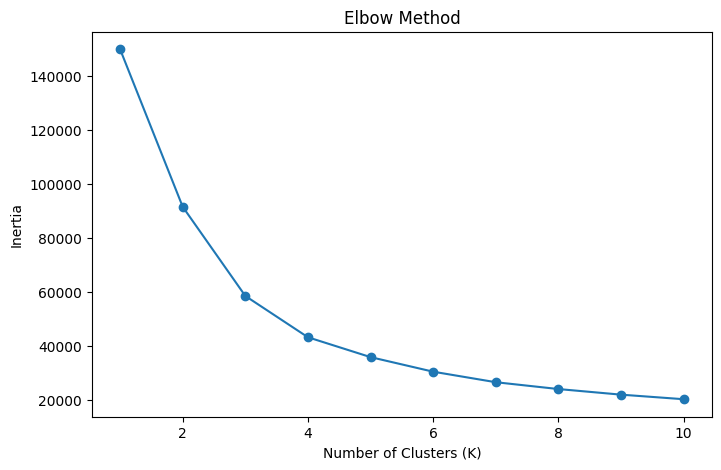

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The elbow chart shows inertia dropping sharply until K=4, then flattening out — meaning 4 clusters capture most of the structure in the data, and adding more clusters gives diminishing returns.

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,CUST-000001,63,28,25552.80,1
1,CUST-000002,342,75,22564.50,3
2,CUST-000003,64,163,108217.33,2
3,CUST-000004,2,192,117811.20,2
4,CUST-000005,4,31,20201.15,1


Applied K-Means with K=4 (chosen from the elbow method) to group all 50,000 customers into 4 clusters based on their Recency, Frequency, and Monetary scores. Each customer now has a Cluster label (0-3) assigned.

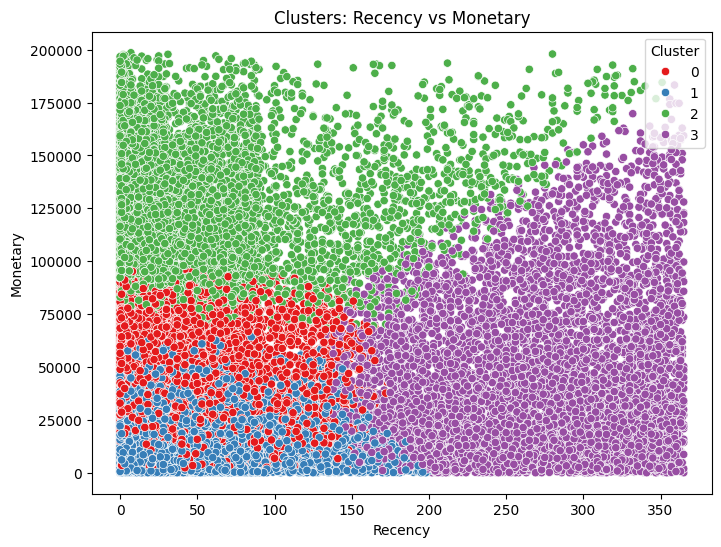

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Clusters: Recency vs Monetary')
plt.show()

Clear separation by recency: customers who purchased recently and spend the most (green) stand apart from customers who haven't purchased in a long time (purple), regardless of how much they used to spend.

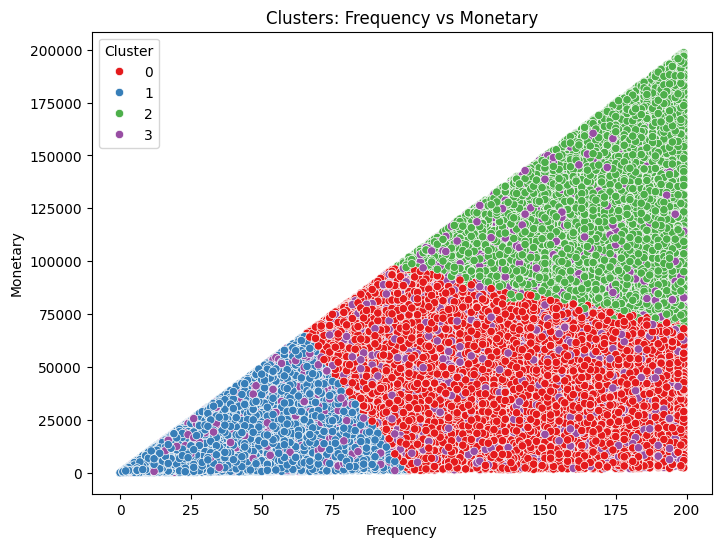

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1')
plt.title('Clusters: Frequency vs Monetary')
plt.show()

Frequency and Monetary rise together — customers who buy often also tend to spend the most (green), while low-frequency customers cluster at low spend (blue), confirming these two features reinforce each other.

In [12]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,26.331733,127.564297,46280.097621
1,28.358826,40.133805,17302.745790
2,39.618684,162.350769,121409.385374
3,266.209710,94.091353,43487.401063


Profiling the 4 clusters reveals distinct customer types: Cluster 2 = Champions (buy often, recently, highest spend), Cluster 0 = Regular/Loyal customers, Cluster 1 = Occasional low-value buyers, and Cluster 3 = At-risk customers who haven't purchased in ~266 days despite decent past spending.

/tmp/ipykernel_3665/2822486000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='Set1')


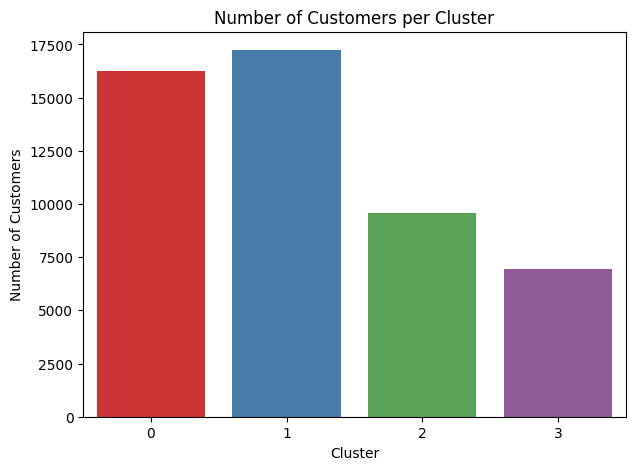

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(data=rfm, x='Cluster', palette='Set1')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

Regular (Cluster 0) and Occasional (Cluster 1) customers make up the bulk of the base (~33,600 combined), while Champions (Cluster 2, ~9,500) and At-risk (Cluster 3, ~7,000) are smaller groups — a healthy shape, since the best customers outnumber the at-risk ones.

Insights — Recommended Marketing Actions per Segment
Cluster 2 — Champions (frequent, recent, highest spend)

These are the most valuable customers. Reward their loyalty with exclusive discounts, early access to new products, or a VIP loyalty program to keep them engaged and prevent them from switching to competitors.

Cluster 0 — Loyal/Regular (buy fairly often, moderate spend)

Solid, dependable customers. Focus on retention rather than heavy discounting — send regular product updates and occasional small incentives to nudge them toward becoming Champions.

Cluster 1 — Occasional/Low-value (buy rarely, low spend)

Send personalized offers and new-arrival notifications to increase their purchase frequency, and consider bundle deals to raise their average order value.

Cluster 3 — At-risk/Lapsed (haven't purchased in ~266 days)

This group needs a win-back campaign — a strong discount, "we miss you" email, or limited-time offer to re-engage them before they churn permanently, since they used to spend a decent amount.